# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [11]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [12]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)

lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

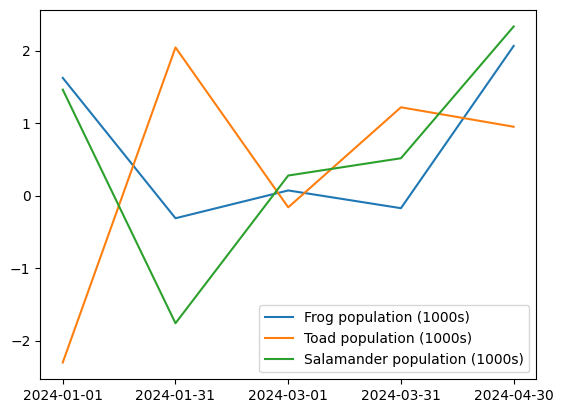

In [13]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

The graph is decent but needs improvement.

**Pros**: clear legend, multiple lines are distinguishable, and it shows trends over time.

**Cons**: missing title, unclear y-axis label, cluttered date labels, weak color contrast, and confusing negative values.

**Fixes**: add a title and axis labels, simplify dates, use better colors and thicker lines, improve contrast, and clarify or correct the negative values.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

In [21]:
# Load the Dataset

df = pd.read_csv("medical_insurance_cleaned")

In [22]:

# Dataset structure
df.info()

# Statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/tmp/ipykernel_6490/2448589732.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_stat, u_p = mannwhitneyu(smokers, nonsmokers)


T-test p-value: nan
Mann-Whitney p-value: nan


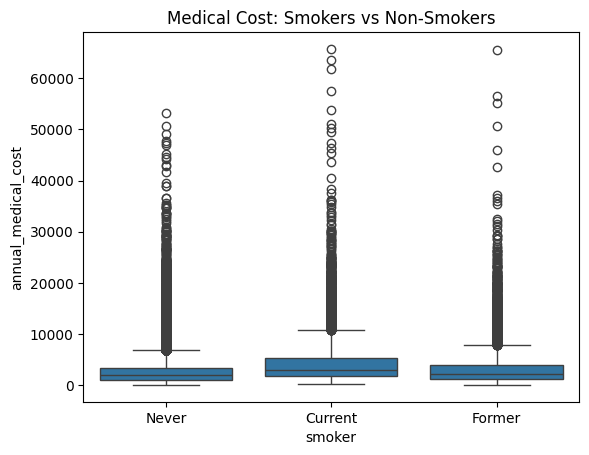

In [24]:
# BEST TEST 1: Smokers vs Non-Smokers (Medical Cost)

from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, chi2_contingency

smokers = df[df['smoker'] == 'yes']['annual_medical_cost']
nonsmokers = df[df['smoker'] == 'no']['annual_medical_cost']

# T-test
t_stat, t_p = ttest_ind(smokers, nonsmokers, equal_var=False)

# Mann-Whitney U test
u_stat, u_p = mannwhitneyu(smokers, nonsmokers)

print("T-test p-value:", t_p)
print("Mann-Whitney p-value:", u_p)

# Visualization
sns.boxplot(x='smoker', y='annual_medical_cost', data=df)
plt.title("Medical Cost: Smokers vs Non-Smokers")
plt.show()

ANOVA p-value: 0.11017292344884047


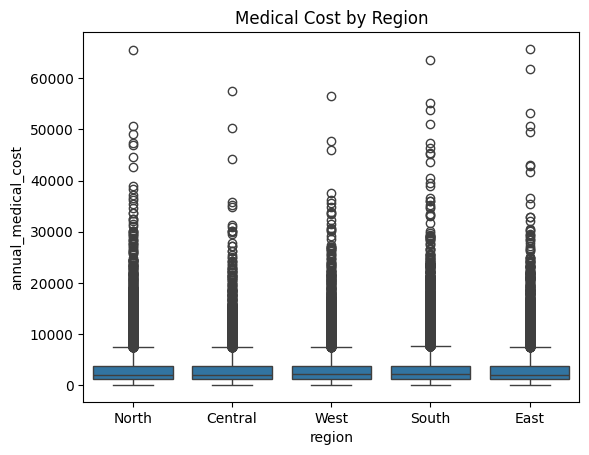

In [25]:
# BEST TEST 2: Region vs Medical Cost (ANOVA)

groups = [group['annual_medical_cost'].values for name, group in df.groupby('region')]

f_stat, f_p = f_oneway(*groups)

print("ANOVA p-value:", f_p)

# Visualization
sns.boxplot(x='region', y='annual_medical_cost', data=df)
plt.title("Medical Cost by Region")
plt.show()

In [26]:
# BEST TEST 3: Smoking vs High Risk (Chi-Square)

contingency = pd.crosstab(df['smoker'], df['is_high_risk'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square p-value:", p)
print(contingency)

Chi-square p-value: 0.0
is_high_risk      0      1
smoker                    
Current        3312   8816
Former        12477   5686
Never         47430  22279


/tmp/ipykernel_6490/3956146477.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['risk_score'].values for name, group in df.groupby('age_group')]


ANOVA (Age vs Risk Score) p-value: 0.0


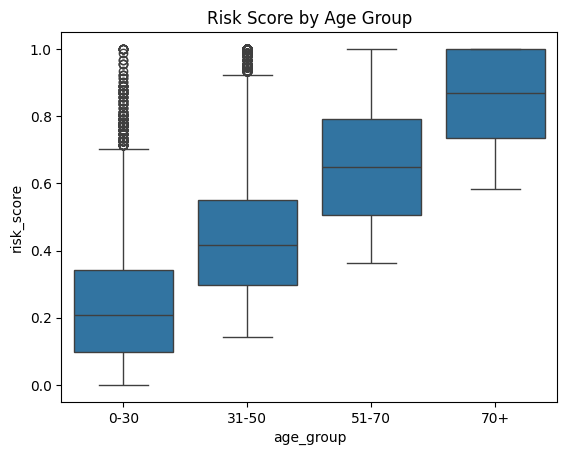

In [27]:
# Age Group vs Risk Score (ANOVA)

# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0,30,50,70,100],
                         labels=['0-30','31-50','51-70','70+'])

groups = [group['risk_score'].values for name, group in df.groupby('age_group')]

f_stat, f_p = f_oneway(*groups)

print("ANOVA (Age vs Risk Score) p-value:", f_p)

sns.boxplot(x='age_group', y='risk_score', data=df)
plt.title("Risk Score by Age Group")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

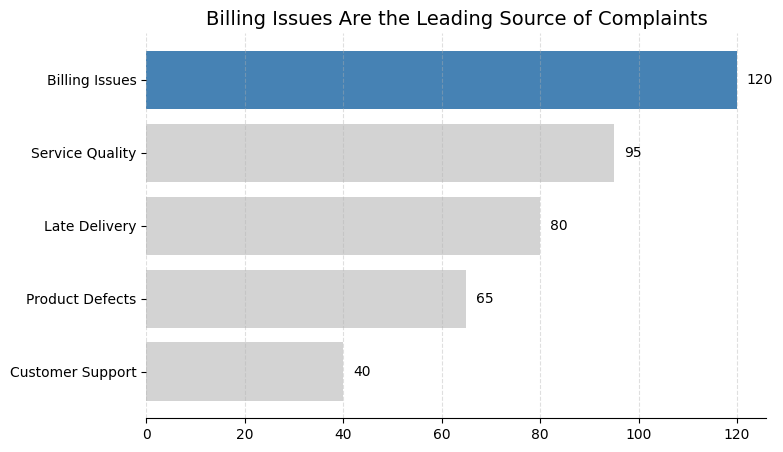

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Example data
data = {
    "Category": [
        "Billing Issues",
        "Service Quality",
        "Late Delivery",
        "Product Defects",
        "Customer Support"
    ],
    "Complaints": [120, 95, 80, 65, 40]
}

df = pd.DataFrame(data)

# Sort values (important for storytelling)
df = df.sort_values(by="Complaints", ascending=True)

# Highlight top category
colors = ["lightgray"] * len(df)
colors[-1] = "steelblue"  # highest value highlighted

# Plot
fig, ax = plt.subplots(figsize=(8,5))

ax.barh(df["Category"], df["Complaints"], color=colors)

# Title communicates insight
ax.set_title("Billing Issues Are the Leading Source of Complaints", fontsize=14)

# Remove clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.4)

# Direct labeling (optional)
for i, v in enumerate(df["Complaints"]):
    ax.text(v + 2, i, str(v), va="center")

plt.show()